In [15]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta, date
import seaborn as sns
from sklearn.metrics import r2_score
from scipy.stats import norm
from typing import Literal
import random
import pickle as pkl

random.seed(1)

In [2]:
call_data = pd.read_csv('call_data_sept_13_clean.csv')
put_data = pd.read_csv('put_data_sept_13_clean.csv')

put_data['expiry_date'] = pd.to_datetime(put_data['expiry_date'], format='%d/%m/%Y')
call_data['expiry_date'] = pd.to_datetime(call_data['expiry_date'], format='%d/%m/%Y')

In [3]:
def generate_profit(df, opt_type):
    if opt_type == "call":
        df['profit'] = np.maximum(-df['strike_price'] + df['closing_price_at_expiry'] - df['live_last_price'], -df['live_last_price'])
    else:  # put
        df['profit'] = np.maximum(df['strike_price'] - df['closing_price_at_expiry'] - df['live_last_price'], -df['live_last_price'])

In [4]:
tickers: dict[str, yf.ticker.Ticker] = {}

def expiry_price(symbol, date):
    if symbol not in tickers:
        tickers[symbol] = yf.ticker.Ticker(symbol)
    return tickers[symbol].history(
        interval="1d", start=date, end=date + timedelta(days=1)
    )['Close'].iloc[0]

def get_expiry_price(df):
    df['closing_price_at_expiry'] = df.apply(
        lambda row: expiry_price(row['stock'], row['expiry_date']),
        axis=1
    )

In [5]:
collection_date = pd.Timestamp(2024, 9, 12)
put_data['time_to_expiry'] = (put_data['expiry_date'] - collection_date).dt.days
call_data['time_to_expiry'] = (call_data['expiry_date'] - collection_date).dt.days

get_expiry_price(put_data)
get_expiry_price(call_data)
generate_profit(put_data, "put")
generate_profit(call_data, "call")

In [6]:
call_data

,Unnamed: 0,stock,expiry_date,strike_price,live_last_price,bsm,sigma,time_to_expiry,closing_price_at_expiry,profit
0,0,NVDA,2024-09-13,50.0,70.30,6.914000e+01,0.514668,1,119.099998,-1.200002
1,1,NVDA,2024-09-13,55.0,57.32,6.414000e+01,0.514668,1,119.099998,6.779998
2,2,NVDA,2024-09-13,57.0,48.10,6.214000e+01,0.514668,1,119.099998,13.999998
3,3,NVDA,2024-09-13,58.0,62.03,6.114000e+01,0.514668,1,119.099998,-0.930002
4,4,NVDA,2024-09-13,59.0,46.42,6.014000e+01,0.514668,1,119.099998,13.679998
...,...,...,...,...,...,...,...,...,...,...
4439,4843,CNQ,2024-09-20,90.0,0.25,2.210000e-150,0.281456,8,33.400002,-0.250000
4440,4844,CNQ,2024-09-20,95.0,0.30,1.710000e-166,0.281456,8,33.400002,-0.300000
4441,4845,CNQ,2024-09-20,100.0,0.30,1.500000e-182,0.281456,8,33.400002,-0.300000
4442,4846,CNQ,2024-09-20,105.0,0.60,1.620000e-198,0.281456,8,33.400002,-0.600000


In [21]:
def bsm_price(df, risk_free_rate, volatility_col, option_type: Literal["call", "put"]):    
    d1 = (np.log(df['stock_price'] / df['strike_price']) + (risk_free_rate + (df[volatility_col] ** 2) / 2) * df['time_to_expiry']) / (df[volatility_col] * np.sqrt(df['time_to_expiry'] / 365))
    d2 = d1 - df[volatility_col] * np.sqrt(df['time_to_expiry'] / 365)

    print(d1)
    print(d2)
    print(norm.cdf(d1))

    if option_type == "call":
        return df['stock_price'] * norm.cdf(d1) - df['strike_price'] * np.exp(-risk_free_rate * df['time_to_expiry'] / 365) * norm.cdf(d2)
    if option_type == "put":
        return df['strike_price'] * np.exp(-risk_free_rate * df['time_to_expiry'] / 365) * norm.cdf(-d2) - df['stock_price'] * norm.cdf(-d1)

In [8]:
def calculate_profit_stats(df, total_num):

    portfolio_size = len(df) / total_num

    num_positive_profit_rows = len(df[df['profit'] >= 0])
    num_negative_profit_rows = len(df[df['profit'] < 0])
    
    percent_positive = (num_positive_profit_rows / len(df)) * 100 
    percent_negative = (num_negative_profit_rows / len(df)) * 100 

    total_profit = df['profit'].sum() / sum(df['live_last_price'])

    return portfolio_size, num_positive_profit_rows, total_profit, percent_positive, percent_negative

In [9]:
def generate_two_pie_charts(stats1, stats2, titles):
    # Unpack the titles
    title1, title2, title3 = titles
    
    # Create a smaller 1x2 subplot structure with adjusted figure size
    fig, axs = plt.subplots(1, 2, figsize=(9, 6))  # Increase the size for a cleaner look

    # Apply a tighter layout with minimal padding
    fig.tight_layout(pad=1.0, h_pad=0.1, w_pad=0.1)  # Reduce overall padding

    # Further adjust spacing between subplots and figure borders
    plt.subplots_adjust(left=0.05, right=0.95, top=0.85, bottom=0.15, wspace=0.05, hspace=0.05)


    # Data for each pie chart
    chart_data = [
        (stats1, axs[0], title1),
        (stats2, axs[1], title2)
    ]

    # Updated colors: rich blue and red
    colors = ['#1bc411', '#f7270f']  # Standard rich blue and red

    # Generate pie charts for each subplot
    for stats, ax, title in chart_data:
        _, _, total_profit, percent_positive, percent_negative = stats
        sizes = [percent_positive, percent_negative]
        labels = ['Won', 'Lost']

        # Create the pie chart
        wedges, texts, autotexts = ax.pie(
            sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11, 'fontweight': 'bold'}
        )
        ax.set_title(title, fontsize=14, weight='bold')
        ax.axis('equal')  # Ensures the pie is drawn as a circle

        # Customize the text properties inside the pie
        for autotext in autotexts:
            autotext.set_fontsize(11)
            autotext.set_weight('bold')
            autotext.set_color('white')  # Change color to white for better readability

        # Customize the labels outside the pie chart ("Won" and "Lost") to match the text style
        for text in texts:
            text.set_fontsize(11)
            text.set_fontweight('bold')

        # Format portfolio size with commas and format total profit using custom format
        formatted_profit = f"{total_profit * 100:.1f}%"
        
        # Add portfolio size and total profit in the center of the pie chart with a custom text box
        textstr = f"ROI: {formatted_profit}"
        ax.text(
            0, 0, textstr, ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
        )

        # Add an overall title to the entire figure
        fig.suptitle(title3, fontsize=18, weight='bold')
        

    plt.show()

In [10]:
import functools

@functools.lru_cache
def get_predictors(symbol, date):
    ticker = yf.Ticker(symbol)
    start_date = date - timedelta(days=14)
    hist = ticker.history(interval="1d", start=start_date, end=date)
    on_day = ticker.history(interval="1d", start=date, end=date+timedelta(days=1))

    log_returns = np.log(hist['Close'] / hist['Close'].shift(1))
    
    return {
        "volume": hist["Volume"].mean(),
        "historical_volatility": log_returns.std() * np.sqrt(252),
        "avg_stock_price": np.mean(hist['Close']),
        "stock_price": on_day['Close'].mean(),
    }

In [13]:
try:
    put_data.drop(columns=['volume', 'historical_volatility', 'avg_stock_price', 'stock_price'], inplace=True)
    call_data.drop(columns=['volume', 'historical_volatility', 'avg_stock_price', 'stock_price'], inplace=True)
except KeyError:
    pass

In [16]:
# Define the date
date = pd.to_datetime("2024-09-12")

# Apply the function to each row in the DataFrame
put_results = put_data['stock'].apply(lambda symbol: get_predictors(symbol, date))
call_results = call_data['stock'].apply(lambda symbol: get_predictors(symbol, date))

# Expand the results into separate columns
put_results = pd.DataFrame(put_results.tolist())
call_results = pd.DataFrame(call_results.tolist())
put_data = pd.concat([put_data, put_results], axis=1)
call_data = pd.concat([call_data, call_results], axis=1).dropna()

In [158]:
lin_regr = pkl.load(open("lin_regr.pkl", "rb"))
knn_regr = pkl.load(open("knn_regr.pkl", "rb"))
gradient_boost_regr = pkl.load(open("gradient_boost_regr.pkl", "rb"))
rand_forest_regr = pkl.load(open("rand_forest_regr.pkl", "rb"))
log_lin_regr = pkl.load(open("log_lin_regr.pkl", "rb"))
log_knn_regr = pkl.load(open("log_knn_regr.pkl", "rb"))
log_gradient_boost_regr = pkl.load(open("log_gradient_boost_regr.pkl", "rb"))
log_rand_forest_regr = pkl.load(open("log_rand_forest_regr.pkl", "rb"))
reg = {
    "lin_regr": lin_regr,
    "knn_regr": knn_regr,
    "gradient_boost_regr": gradient_boost_regr,
    "rand_forest_regr": rand_forest_regr,
    "log_lin_regr": log_lin_regr,
    "log_knn_regr": log_knn_regr,
    "log_gradient_boost_regr": log_gradient_boost_regr,
    "log_rand_forest_regr": log_rand_forest_regr,
}

In [165]:
def predict_volatiltiy(model_name, data, opt_type, log=False):
    predictors = data[['volume', 'historical_volatility', 'avg_stock_price']].rename(columns={
        'volume': 'Volume',
        'historical_volatility': 'Historical Volatility',
        'avg_stock_price': 'Stock Price',
    })

    if log:
        tmp = np.exp(reg[f'{model_name}_regr'].predict(predictors))
    else:
        tmp = reg[f'{model_name}_regr'].predict(predictors)
    print(tmp)
    data[f'{model_name}_volatility_ml'] = tmp
    print(data[f'{model_name}_volatility_ml'])
    data[f'{model_name}_bsm_ml'] = bsm_price(data, 0.0525, f'{model_name}_volatility_ml', opt_type).clip(lower=0)

predict_volatiltiy("gradient_boost", call_data, "call")
predict_volatiltiy("gradient_boost", put_data, "put")

[0.51669142 0.51669142 0.51669142 ... 0.31110124 0.31110124 0.31110124]
0       0.516691
1       0.516691
2       0.516691
3       0.516691
4       0.516691
          ...   
4439    0.311101
4440    0.311101
4441    0.311101
4442    0.311101
4443    0.311101
Name: gradient_boost_volatility_ml, Length: 4444, dtype: float64
0       38.981939
1       35.457788
2       34.137091
3       33.494021
4       32.861944
          ...    
4439    -4.756289
4440    -5.930196
4441    -7.043876
4442    -8.103207
4443    -9.113250
Length: 4444, dtype: float64
0       38.954894
1       35.430743
2       34.110046
3       33.466976
4       32.834899
          ...    
4439    -4.802346
4440    -5.976254
4441    -7.089933
4442    -8.149265
4443    -9.159307
Length: 4444, dtype: float64
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 9.34824492e-13
 2.67644197e-16 3.99752448e-20]
[0.51669142 0.51669142 0.51669142 ... 0.31110124 0.31110124 0.31110124]
0       0.516691
1       0.516691
2       0.516691
3 

In [ ]:
g = sns.PairGrid(put_data, vars=['live_last_price', 'bsm', 'ML bsm'], hue='stock')
g.map_diag(sns.histplot)
g.map_lower(sns.scatterplot)

In [174]:
call_data

,Unnamed: 0,stock,expiry_date,strike_price,live_last_price,bsm,sigma,time_to_expiry,closing_price_at_expiry,profit,...,knn_bsm_ml,lin_bsm_ml,log_gradient_boost_volatility_ml,log_gradient_boost_bsm_ml,log_knn_volatility_ml,log_knn_bsm_ml,log_rand_forest_volatility_ml,log_rand_forest_bsm_ml,log_lin_volatility_ml,log_lin_bsm_ml
0,0,NVDA,2024-09-13,50.0,70.30,6.914000e+01,0.514668,1,119.099998,-1.200002,...,69.147191,69.147191,0.515665,69.147191,0.249896,69.147191,0.358314,69.147191,0.578795,69.147191
1,1,NVDA,2024-09-13,55.0,57.32,6.414000e+01,0.514668,1,119.099998,6.779998,...,64.147910,64.147910,0.515665,64.147910,0.249896,64.147910,0.358314,64.147910,0.578795,64.147910
2,2,NVDA,2024-09-13,57.0,48.10,6.214000e+01,0.514668,1,119.099998,13.999998,...,62.148197,62.148197,0.515665,62.148197,0.249896,62.148197,0.358314,62.148197,0.578795,62.148197
3,3,NVDA,2024-09-13,58.0,62.03,6.114000e+01,0.514668,1,119.099998,-0.930002,...,61.148341,61.148341,0.515665,61.148341,0.249896,61.148341,0.358314,61.148341,0.578795,61.148341
4,4,NVDA,2024-09-13,59.0,46.42,6.014000e+01,0.514668,1,119.099998,13.679998,...,60.148485,60.148485,0.515665,60.148485,0.249896,60.148485,0.358314,60.148485,0.578795,60.148485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4439,4843,CNQ,2024-09-20,90.0,0.25,2.210000e-150,0.281456,8,33.400002,-0.250000,...,0.000000,0.000000,0.285647,0.000000,0.249896,0.000000,0.322042,0.000000,0.215206,0.000000
4440,4844,CNQ,2024-09-20,95.0,0.30,1.710000e-166,0.281456,8,33.400002,-0.300000,...,0.000000,0.000000,0.285647,0.000000,0.249896,0.000000,0.322042,0.000000,0.215206,0.000000
4441,4845,CNQ,2024-09-20,100.0,0.30,1.500000e-182,0.281456,8,33.400002,-0.300000,...,0.000000,0.000000,0.285647,0.000000,0.249896,0.000000,0.322042,0.000000,0.215206,0.000000
4442,4846,CNQ,2024-09-20,105.0,0.60,1.620000e-198,0.281456,8,33.400002,-0.600000,...,0.000000,0.000000,0.285647,0.000000,0.249896,0.000000,0.322042,0.000000,0.215206,0.000000


In [184]:
def get_portfolio(df, prediction_col):
    underpriced = df[df['live_last_price'] <= df[prediction_col]]
    overpriced = df[df['live_last_price'] > df[prediction_col]]
    return underpriced, overpriced

def generate_four_pie_charts(stats1, stats2, stats3, stats4, titles, save_file = None):
    """
    Taken from analysing_options_price_data.ipynb
    """
    # Unpack the titles
    title1, title2, title3, title4, title5 = titles
    
    # Create a smaller 2x2 subplot structure with adjusted figure size
    fig, axs = plt.subplots(2, 2, figsize=(7, 7))  # Increase the size for a cleaner look

    # Data for each pie chart
    chart_data = [
        (stats1, axs[0, 0], title1),
        (stats2, axs[0, 1], title2),
        (stats3, axs[1, 0], title3),
        (stats4, axs[1, 1], title4)
    ]

    # Updated colors: rich blue and red
    colors = ['#1bc411', '#f7270f']  # Standard rich blue and red

    # Generate pie charts for each subplot
    for stats, ax, title in chart_data:
        portfolio_size, _, total_profit, percent_positive, percent_negative = stats
        sizes = [percent_positive, percent_negative]
        labels = ['Won', 'Lost']

        # Create the pie chart
        wedges, texts, autotexts = ax.pie(
            sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=40, textprops={'fontsize': 9}
        )
        ax.set_title(title, fontsize=11, weight='bold')
        ax.axis('equal')  # Ensures the pie is drawn as a circle

        # Customize the text properties inside the pie
        for autotext in autotexts:
            autotext.set_fontsize(10)
            autotext.set_weight('bold')
            autotext.set_color('white')  # Change color to white for better readability

        # Customize the labels outside the pie chart ("Won" and "Lost") to match the text style
        for text in texts:
            text.set_fontsize(10)
            

        # Format portfolio size with commas and format total profit using custom format
        formatted_profit = f"{total_profit * 100:.1f}%"
        formatted_size = f"{portfolio_size * 100:.1f}%"  # Display size as a percentage with 2 decimal places


        # Add portfolio size and total profit in the center of the pie chart with a custom text box
        textstr = f"Size: {formatted_size}\nROI: {formatted_profit}"
        ax.text(
            0, 0, textstr, ha='center', va='center', fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
        )


    # Add an overall title to the entire figure
    fig.suptitle(title5, fontsize=14, weight = 'bold')
    
    # Display the pie charts
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Adjust layout to fit the main title
    if save_file:
        plt.savefig(save_file)
    else:
        plt.show()

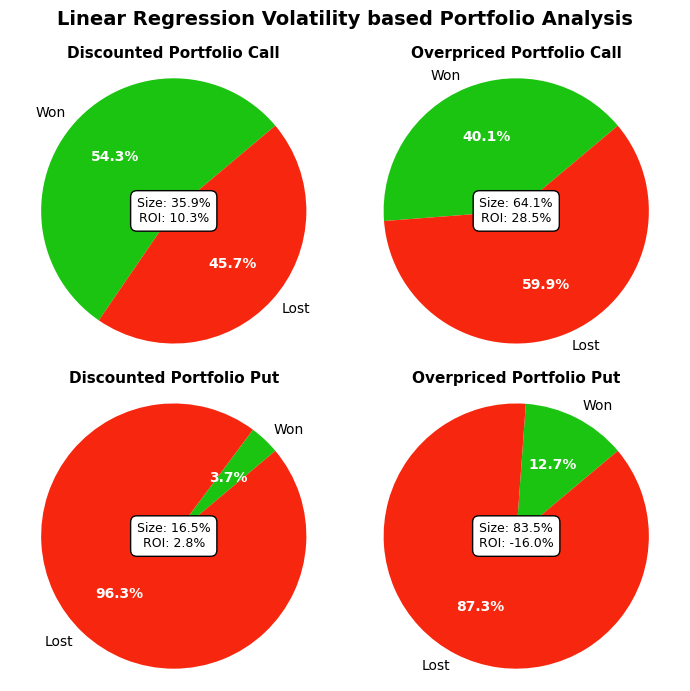

In [81]:
underprice_put, overpriced_put = get_portfolio(put_data, 'ML bsm')
underprice_call, overpriced_call = get_portfolio(call_data, 'ML bsm')

s1, s2 = calculate_profit_stats(underprice_put, len(put_data)), calculate_profit_stats(overpriced_put, len(put_data))
s3, s4 = calculate_profit_stats(underprice_call, len(call_data)), calculate_profit_stats(overpriced_call, len(call_data))

titles = [
    "Discounted Portfolio Call",
    "Overpriced Portfolio Call",
    "Discounted Portfolio Put",
    "Overpriced Portfolio Put",
    "Linear Regression Volatility based Portfolio Analysis"
]

# Generate a single figure with four pie charts using the updated stats
generate_four_pie_charts(
    s3, s4, s1, s2, titles, "ml_four_plot.png")
plt.savefig('update_plot.png')

In [178]:
put_data

,Unnamed: 0,stock,expiry_date,strike_price,live_last_price,bsm,sigma,Unnamed: 7,time_to_expiry,closing_price_at_expiry,...,lin_volatility_ml,lin_bsm_ml,log_gradient_boost_volatility_ml,log_gradient_boost_bsm_ml,log_knn_volatility_ml,log_knn_bsm_ml,log_rand_forest_volatility_ml,log_rand_forest_bsm_ml,log_lin_volatility_ml,log_lin_bsm_ml
0,0,NVDA,2024-09-13,50.0,0.01,0.000000,0.514668,0,1,119.099998,...,0.560137,1.284422e-294,0.515665,0.000000e+00,0.249896,0.000000,0.358314,0.000000,0.578795,2.027290e-281
1,1,NVDA,2024-09-13,55.0,0.01,0.000000,0.514668,0,1,119.099998,...,0.560137,5.584668e-245,0.515665,4.381373e-275,0.249896,0.000000,0.358314,0.000000,0.578795,1.896190e-234
2,2,NVDA,2024-09-13,57.0,0.01,0.000000,0.514668,0,1,119.099998,...,0.560137,1.472373e-227,0.515665,4.844200e-255,0.249896,0.000000,0.358314,0.000000,0.578795,5.946718e-218
3,3,NVDA,2024-09-13,58.0,0.01,0.000000,0.514668,0,1,119.099998,...,0.560137,2.615161e-219,0.515665,1.478144e-245,0.249896,0.000000,0.358314,0.000000,0.578795,3.875591e-210
4,4,NVDA,2024-09-13,59.0,0.01,0.000000,0.514668,0,1,119.099998,...,0.560137,2.383320e-211,0.515665,2.072603e-236,0.249896,0.000000,0.358314,0.000000,0.578795,1.347375e-202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4246,4577,CNQ,2024-09-20,75.0,6.00,42.284525,0.281456,1,8,33.400002,...,0.278883,4.255421e+01,0.285647,4.229434e+01,0.249896,42.660712,0.322042,25.928610,0.215206,4.266075e+01
4247,4578,CNQ,2024-09-20,77.5,5.50,44.782009,0.281456,1,8,33.400002,...,0.278883,4.515071e+01,0.285647,4.512192e+01,0.249896,45.157875,0.322042,37.550704,0.215206,4.515787e+01
4248,4579,CNQ,2024-09-20,80.0,6.90,47.279493,0.281456,1,8,33.400002,...,0.278883,4.765470e+01,0.285647,4.765277e+01,0.249896,47.655000,0.322042,45.174345,0.215206,4.765500e+01
4249,4580,CNQ,2024-09-20,82.5,7.40,49.776977,0.281456,1,8,33.400002,...,0.278883,5.015212e+01,0.285647,5.015203e+01,0.249896,50.152125,0.322042,49.569871,0.215206,5.015212e+01


/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


0       34.434725
1       31.479645
2       30.372210
3       29.832981
4       29.302971
          ...    
4246     6.904161
4247     6.440296
4248     5.991158
4249     5.555843
4250     5.133524
Length: 4251, dtype: float64
0       34.402472
1       31.447392
2       30.339957
3       29.800728
4       29.270718
          ...    
4246     6.833473
4247     6.369607
4248     5.920470
4249     5.485155
4250     5.062836
Length: 4251, dtype: float64
[1.         1.         1.         ... 1.         0.99999999 0.99999986]
0       34.434725
1       31.479645
2       30.372210
3       29.832981
4       29.302971
          ...    
4246     6.904161
4247     6.440296
4248     5.991158
4249     5.555843
4250     5.133524
Length: 4251, dtype: float64
0       34.402472
1       31.447392
2       30.339957
3       29.800728
4       29.270718
          ...    
4246     6.833473
4247     6.369607
4248     5.920470
4249     5.485155
4250     5.062836
Length: 4251, dtype: float64
[1.         1.      

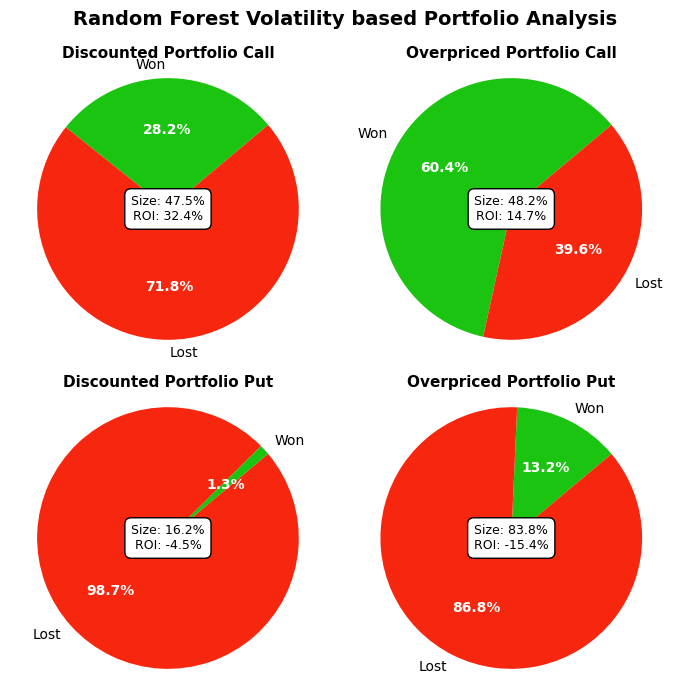

In [82]:
predict_volatiltiy("rand_forest", call_data, "call")
predict_volatiltiy("rand_forest", put_data, "put")

underprice_put, overpriced_put = get_portfolio(put_data, 'rand_forest_bsm_ml')
underprice_call, overpriced_call = get_portfolio(call_data, 'rand_forest_bsm_ml')

s1, s2 = calculate_profit_stats(underprice_put, len(put_data)), calculate_profit_stats(overpriced_put, len(put_data))
s3, s4 = calculate_profit_stats(underprice_call, len(call_data)), calculate_profit_stats(overpriced_call, len(call_data))

titles = [
    "Discounted Portfolio Call",
    "Overpriced Portfolio Call",
    "Discounted Portfolio Put",
    "Overpriced Portfolio Put",
    "Random Forest Volatility based Portfolio Analysis"
]

# Generate a single figure with four pie charts using the updated stats
generate_four_pie_charts(
    s3, s4, s1, s2, titles, "ml_four_plot.png")

In [168]:
def create_portfolio_chart(model_name, full_name):
    predict_volatiltiy(model_name, call_data, "call")
    predict_volatiltiy(model_name, put_data, "put")
    
    underprice_put, overpriced_put = get_portfolio(put_data, f'{model_name}_bsm_ml')
    underprice_call, overpriced_call = get_portfolio(call_data, f'{model_name}_bsm_ml')
    
    s1, s2 = calculate_profit_stats(underprice_put, len(put_data)), calculate_profit_stats(overpriced_put, len(put_data))
    s3, s4 = calculate_profit_stats(underprice_call, len(call_data)), calculate_profit_stats(overpriced_call, len(call_data))
    
    titles = [
        "Discounted Portfolio Call",
        "Overpriced Portfolio Call",
        "Discounted Portfolio Put",
        "Overpriced Portfolio Put",
        f"{full_name} Volatility based Portfolio Analysis"
    ]
    
    # Generate a single figure with four pie charts using the updated stats
    generate_four_pie_charts(
        s3, s4, s1, s2, titles, f"{model_name}_portfolio.png")

def create_log_portfolio_chart(model_name, full_name):
    predict_volatiltiy(model_name, call_data, "call", log=True)
    predict_volatiltiy(model_name, put_data, "put", log=True)
    
    underprice_put, overpriced_put = get_portfolio(put_data, f'{model_name}_bsm_ml')
    underprice_call, overpriced_call = get_portfolio(call_data, f'{model_name}_bsm_ml')
    
    s1, s2 = calculate_profit_stats(underprice_put, len(put_data)), calculate_profit_stats(overpriced_put, len(put_data))
    s3, s4 = calculate_profit_stats(underprice_call, len(call_data)), calculate_profit_stats(overpriced_call, len(call_data))
    
    titles = [
        "Discounted Portfolio Call",
        "Overpriced Portfolio Call",
        "Discounted Portfolio Put",
        "Overpriced Portfolio Put",
        f"{full_name} Volatility based Portfolio Analysis"
    ]
    
    # Generate a single figure with four pie charts using the updated stats
    generate_four_pie_charts(
        s3, s4, s1, s2, titles, f"{model_name}_portfolio.png")

/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


[0.31009445 0.31009445 0.31009445 ... 0.31009447 0.31009447 0.31009447]
0       0.310094
1       0.310094
2       0.310094
3       0.310094
4       0.310094
          ...   
4439    0.310094
4440    0.310094
4441    0.310094
4442    0.310094
4443    0.310094
Name: knn_volatility_ml, Length: 4444, dtype: float64
0       59.691360
1       53.819283
2       51.618685
3       50.547177
4       49.493986
          ...    
4439    -4.826222
4440    -6.003940
4441    -7.121236
4442    -8.184007
4443    -9.197328
Length: 4444, dtype: float64
0       59.675128
1       53.803052
2       51.602454
3       50.530946
4       49.477755
          ...    
4439    -4.872130
4440    -6.049849
4441    -7.167144
4442    -8.229915
4443    -9.243237
Length: 4444, dtype: float64
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 5.34818303e-13
 1.37279349e-16 1.83480002e-20]
[0.31009445 0.31009445 0.31009445 ... 0.31009447 0.31009447 0.31009447]
0       0.310094
1       0.310094
2       0.310094
3       0.310

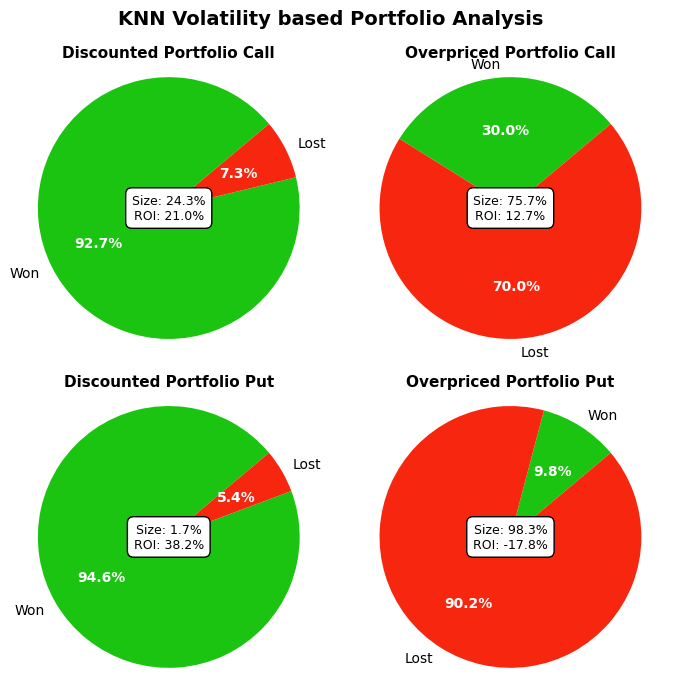

In [185]:
create_portfolio_chart("knn", "KNN")

[0.56013734 0.56013734 0.56013734 ... 0.27888335 0.27888335 0.27888335]
0       0.560137
1       0.560137
2       0.560137
3       0.560137
4       0.560137
          ...   
4439    0.278883
4440    0.278883
4441    0.278883
4442    0.278883
4443    0.278883
Name: lin_volatility_ml, Length: 4444, dtype: float64
0       36.756227
1       33.505420
2       32.287159
3       31.693968
4       31.110917
          ...    
4439    -7.147277
4440    -8.456800
4441    -9.699137
4442   -10.880847
4443   -12.007574
Length: 4444, dtype: float64
0       36.726908
1       33.476101
2       32.257841
3       31.664649
4       31.081598
          ...    
4439    -7.188565
4440    -8.498087
4441    -9.740424
4442   -10.922135
4443   -12.048862
Length: 4444, dtype: float64
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 1.52030151e-22
 7.11173123e-28 1.62107936e-33]
[0.56013734 0.56013734 0.56013734 ... 0.27888335 0.27888335 0.27888335]
0       0.560137
1       0.560137
2       0.560137
3       0.560

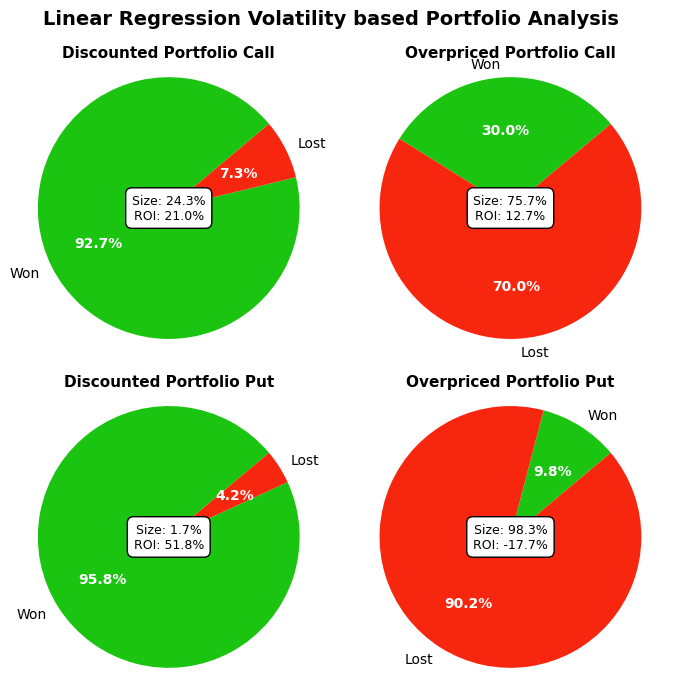

In [186]:
create_portfolio_chart("lin", "Linear Regression")

/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


[0.59667955 0.59667955 0.59667955 ... 0.51395376 0.51395376 0.51395376]
0       0.596680
1       0.596680
2       0.596680
3       0.596680
4       0.596680
          ...   
4439    0.513954
4440    0.513954
4441    0.513954
4442    0.513954
4443    0.513954
Name: rand_forest_volatility_ml, Length: 4444, dtype: float64
0       35.181940
1       32.130221
2       30.986570
3       30.429707
4       29.882363
          ...    
4439     5.919311
4440     5.208733
4441     4.534612
4442     3.893388
4443     3.282000
Length: 4444, dtype: float64
0       35.150708
1       32.098989
2       30.955338
3       30.398475
4       29.851132
          ...    
4439     5.843222
4440     5.132644
4441     4.458523
4442     3.817299
4443     3.205911
Length: 4444, dtype: float64
[1.         1.         1.         ... 0.99999711 0.99995057 0.99948463]
[0.59667955 0.59667955 0.59667955 ... 0.51395376 0.51395376 0.51395376]
0       0.596680
1       0.596680
2       0.596680
3       0.596680
4       0.596

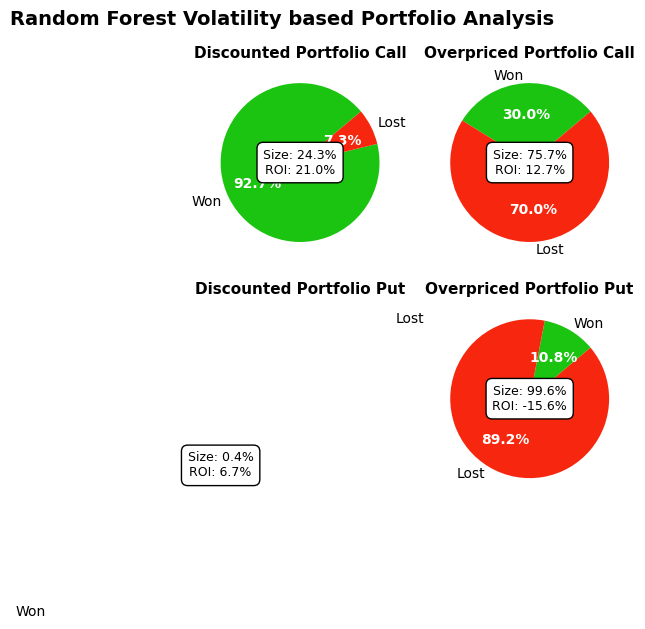

In [193]:
create_portfolio_chart("rand_forest", "Random Forest")

[0.51669142 0.51669142 0.51669142 ... 0.31110124 0.31110124 0.31110124]
0       0.516691
1       0.516691
2       0.516691
3       0.516691
4       0.516691
          ...   
4439    0.311101
4440    0.311101
4441    0.311101
4442    0.311101
4443    0.311101
Name: gradient_boost_volatility_ml, Length: 4444, dtype: float64
0       38.981939
1       35.457788
2       34.137091
3       33.494021
4       32.861944
          ...    
4439    -4.756289
4440    -5.930196
4441    -7.043876
4442    -8.103207
4443    -9.113250
Length: 4444, dtype: float64
0       38.954894
1       35.430743
2       34.110046
3       33.466976
4       32.834899
          ...    
4439    -4.802346
4440    -5.976254
4441    -7.089933
4442    -8.149265
4443    -9.159307
Length: 4444, dtype: float64
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 9.34824492e-13
 2.67644197e-16 3.99752448e-20]
[0.51669142 0.51669142 0.51669142 ... 0.31110124 0.31110124 0.31110124]
0       0.516691
1       0.516691
2       0.516691
3 

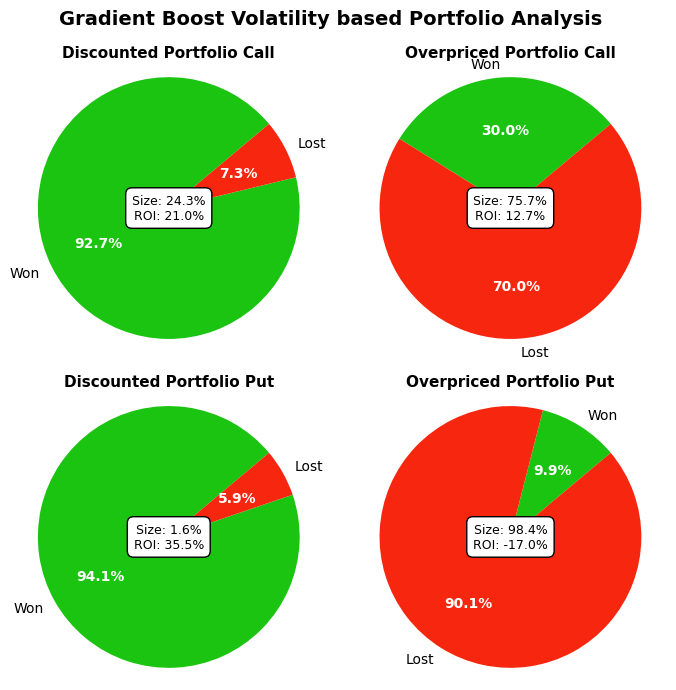

In [188]:
create_portfolio_chart("gradient_boost", "Gradient Boost")

[0.57879504 0.57879504 0.57879504 ... 0.21520618 0.21520618 0.21520618]
0       0.578795
1       0.578795
2       0.578795
3       0.578795
4       0.578795
          ...   
4439    0.215206
4440    0.215206
4441    0.215206
4442    0.215206
4443    0.215206
Name: log_lin_volatility_ml, Length: 4444, dtype: float64
0       35.922084
1       32.776068
2       31.597079
3       31.023009
4       30.458753
          ...    
4439   -13.212070
4440   -14.909066
4441   -16.518997
4442   -18.050363
4443   -19.510476
Length: 4444, dtype: float64
0       35.891788
1       32.745772
2       31.566783
3       30.992714
4       30.428457
          ...    
4439   -13.243931
4440   -14.940927
4441   -16.550858
4442   -18.082224
4443   -19.542337
Length: 4444, dtype: float64
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 1.33907272e-61
 3.91869828e-73 4.47224671e-85]
[0.57879504 0.57879504 0.57879504 ... 0.21520618 0.21520618 0.21520618]
0       0.578795
1       0.578795
2       0.578795
3       0

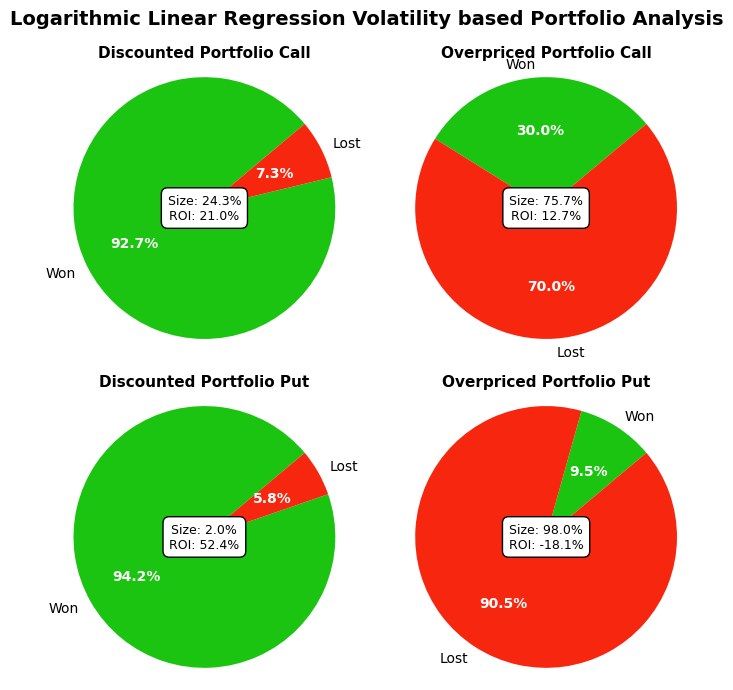

In [189]:
create_log_portfolio_chart("log_lin", "Logarithmic Linear Regression")

/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


[0.24989614 0.24989614 0.24989614 ... 0.24989616 0.24989616 0.24989616]
0       0.249896
1       0.249896
2       0.249896
3       0.249896
4       0.249896
          ...   
4439    0.249896
4440    0.249896
4441    0.249896
4442    0.249896
4443    0.249896
Name: log_knn_volatility_ml, Length: 4444, dtype: float64
0       72.781998
1       65.495377
2       62.764670
3       61.435043
4       60.128145
          ...    
4439    -9.633570
4440   -11.094993
4441   -12.481437
4442   -13.800222
4443   -15.057646
Length: 4444, dtype: float64
0       72.768917
1       65.482297
2       62.751590
3       61.421963
4       60.115065
          ...    
4439    -9.670566
4440   -11.131989
4441   -12.518433
4442   -13.837219
4443   -15.094643
Length: 4444, dtype: float64
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 4.71349169e-36
 1.27033818e-43 1.53771313e-51]
[0.24989614 0.24989614 0.24989614 ... 0.24989616 0.24989616 0.24989616]
0       0.249896
1       0.249896
2       0.249896
3       0

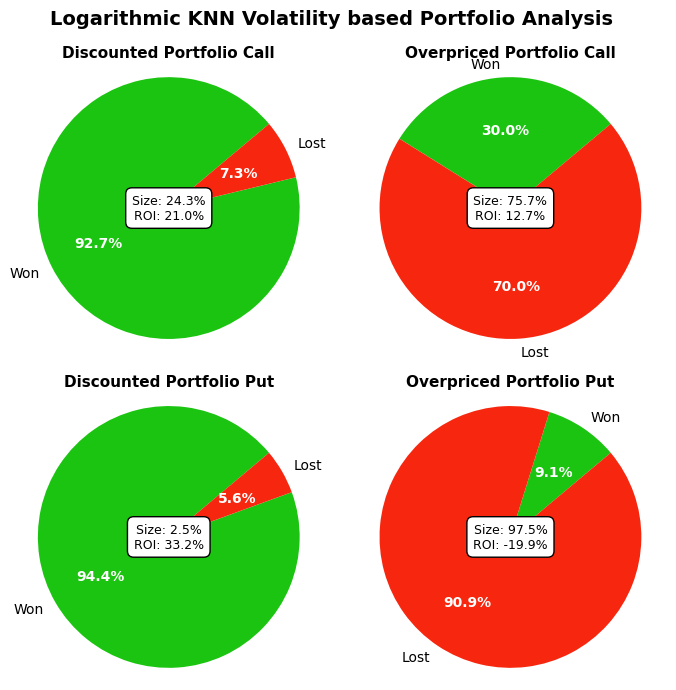

In [190]:
create_log_portfolio_chart("log_knn", "Logarithmic KNN")

/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/martin/Desktop/uni/2024/2024-sem2/MATH3888/project/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


[0.35831412 0.35831412 0.35831412 ... 0.32204171 0.32204171 0.32204171]
0       0.358314
1       0.358314
2       0.358314
3       0.358314
4       0.358314
          ...   
4439    0.322042
4440    0.322042
4441    0.322042
4442    0.322042
4443    0.322042
Name: log_rand_forest_volatility_ml, Length: 4444, dtype: float64
0       52.517719
1       47.435869
2       45.531415
3       44.604103
4       43.692644
          ...    
4439    -4.013558
4440    -5.147585
4441    -6.223431
4442    -7.246775
4443    -8.222504
Length: 4444, dtype: float64
0       52.498964
1       47.417114
2       45.512660
3       44.585348
4       43.673889
          ...    
4439    -4.061236
4440    -5.195262
4441    -6.271108
4442    -7.294452
4443    -8.270181
Length: 4444, dtype: float64
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 2.43199744e-10
 2.13406621e-13 9.96492188e-17]
[0.35831412 0.35831412 0.35831412 ... 0.32204171 0.32204171 0.32204171]
0       0.358314
1       0.358314
2       0.358314
3

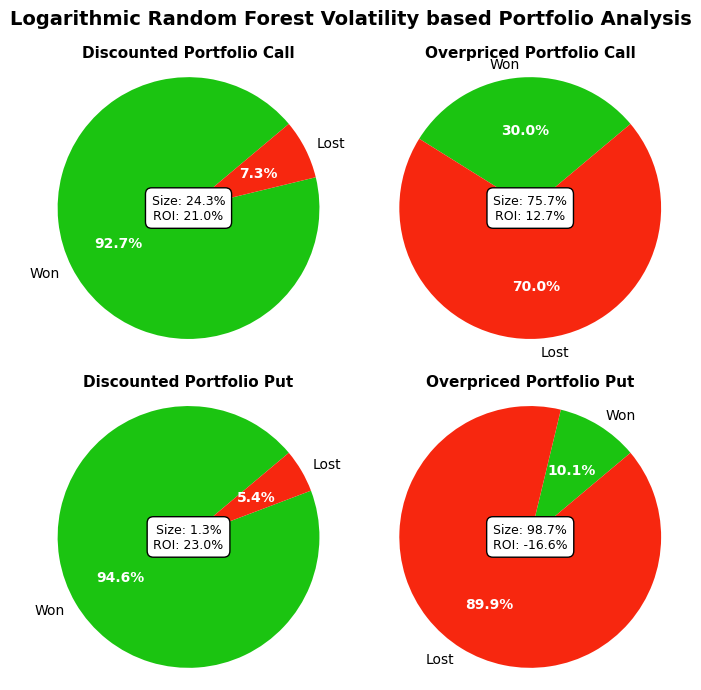

In [191]:
create_log_portfolio_chart("log_rand_forest", "Logarithmic Random Forest")

[0.51566509 0.51566509 0.51566509 ... 0.28564679 0.28564679 0.28564679]
0       0.515665
1       0.515665
2       0.515665
3       0.515665
4       0.515665
          ...   
4439    0.285647
4440    0.285647
4441    0.285647
4442    0.285647
4443    0.285647
Name: log_gradient_boost_volatility_ml, Length: 4444, dtype: float64
0       39.039897
1       35.508732
2       34.185406
3       33.541056
4       32.907721
          ...    
4439    -6.616898
4440    -7.895413
4441    -9.108335
4442   -10.262065
4443   -11.362114
Length: 4444, dtype: float64
0       39.012906
1       35.481741
2       34.158415
3       33.514065
4       32.880730
          ...    
4439    -6.659187
4440    -7.937702
4441    -9.150624
4442   -10.304354
4443   -11.404403
Length: 4444, dtype: float64
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 4.18279928e-20
 5.22242334e-25 3.22815039e-30]
[0.51566509 0.51566509 0.51566509 ... 0.28564679 0.28564679 0.28564679]
0       0.515665
1       0.515665
2       0.51566

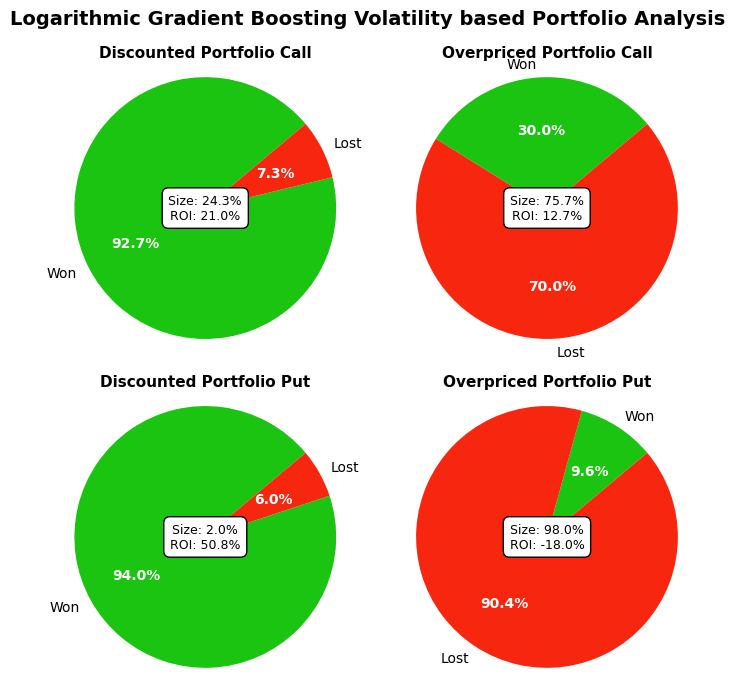

In [192]:
create_log_portfolio_chart("log_gradient_boost", "Logarithmic Gradient Boosting")